# PhyloGeoPlot Raster Visualization - Complete Walkthrough

This notebook demonstrates how to use the refactored `PhyloGeoPlotter` class to create phylogeographic visualizations with both **raster layers** and **geographic maps**.

## What You'll Learn:
- Import and initialize `PhyloGeoPlotter`
- Create visualizations with raster data
- Create visualizations with geographic maps
- Customize colors, contrast, and parameters
- Save outputs as SVG and PNG

## Setup

Configure paths to find your data and scripts.

In [1]:
import sys
from pathlib import Path

# Find workflow directory and add scripts to path
def find_workflow_dir():
    """Find workflow_dir by looking for the input and scripts folders"""
    current = Path.cwd()
    
    # First check current directory
    if (current / 'examples/sample_data/use_case_1').exists() and (current / 'phylocartoplot').exists():
        return current
    
    # Check parent
    if (current.parent / 'examples/sample_data/use_case_1').exists() and (current.parent / 'phylocartoplot').exists():
        return current.parent
    
    # Check grandparent
    if (current.parent.parent / 'examples/sample_data/use_case_1').exists() and (current.parent.parent / 'phylocartoplot').exists():
        return current.parent.parent
    
    # If not found, raise error
    raise FileNotFoundError("Could not find workflow directory with 'input' and 'phylocartoplot' folders")

workflow_dir = find_workflow_dir()

# Construct paths
input_dir = workflow_dir / 'examples/sample_data/use_case_1'
output_dir = workflow_dir / 'output'
preprocessing_dir = workflow_dir / 'phylocartoplot' / 'preprocessing'
visualization_dir = workflow_dir / 'phylocartoplot' / 'visualization'

# Add visualization scripts to path
sys.path.insert(0, str(visualization_dir))

print("Workflow Configuration")
print("="*70)
print(f"Workflow:       {workflow_dir}")
#print(f"Scripts:        {scripts_dir}")
print(f"Visualization:  {visualization_dir}")
print(f"Input:          {input_dir}")
print(f"Output:         {output_dir}")
print("="*70)
print("\n✓ Paths configured")

Workflow Configuration
Workflow:       c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot
Visualization:  c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\phylocartoplot\visualization
Input:          c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1
Output:         c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output

✓ Paths configured


## Import Classes

Import `PhyloGeoPlotter` from the visualization module.

In [ ]:
from phylocartoplot.visualisation.tree_to_map_raster import PhyloGeoPlotter

print("✓ PhyloGeoPlotter imported successfully")

✓ PhyloGeoPlotter imported successfully


## Example 1: Visualization with Raster Layer

Create a phylogeographic visualization with an environmental raster layer as the background.

In [3]:
# Initialize plotter with raster data 
plotter_raster = PhyloGeoPlotter(
    nwk_file=str(input_dir / 'aligned_caffeine_without_nodes_w_no_coords_tree.nwk'),
    gps_file=str(input_dir / 'coords_w_caff_wout_no_caff_nodes.csv'),
    offset_file=str(input_dir / 'offsets_caff.csv'),
    raster_file=str(input_dir / 'madaclim_enviro.tif'),
    raster_band=1,  # Band 1 = Altitude
    raster_metadata_file=str(input_dir / 'env_metadata.json'),
    raster_contrast='histogram_eq',  # High contrast enhancement
    raster_cmap='terrain',
    vmin=0.01,
    vmax=0.06,
    trait_name='Caffeine Content (dmb%)',
    verbose=True
)

print("\n✓ Plotter initialized")

PhyloGeoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\aligned_caffeine_without_nodes_w_no_coords_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\coords_w_caff_wout_no_caff_nodes.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\offsets_caff.csv
  ✓ Loaded tree with 21 species
  ✓ Loaded 454 GPS records
  ✓ Loaded 48 node offsets

Raster file: madaclim_enviro.tif
Total bands: 9
CRS: EPSG:32738
Shape: 1528 x 803
--------------------------------------------------------------------------------
Band 1: alt      | Altitude (meters)
Band 2: slo      | Slope (degrees)
Band 3: asp      | Aspect; clockwise from North (degrees)
Band 4: solrad   | Solar radiation (Wh.m-2.day-1)
Band 5: geo      | Rock types (Geology)
Band 6: soi      | Soil types
Band 7: veg

### Create the Plot


Creating visualization...
  ✓ Tree plotted
  ✓ Enhancing raster contrast (histogram_eq)...
  ✓ Raster plotted with contrast enhancement
  ✓ Colorbar added
  ✓ Connection lines drawn


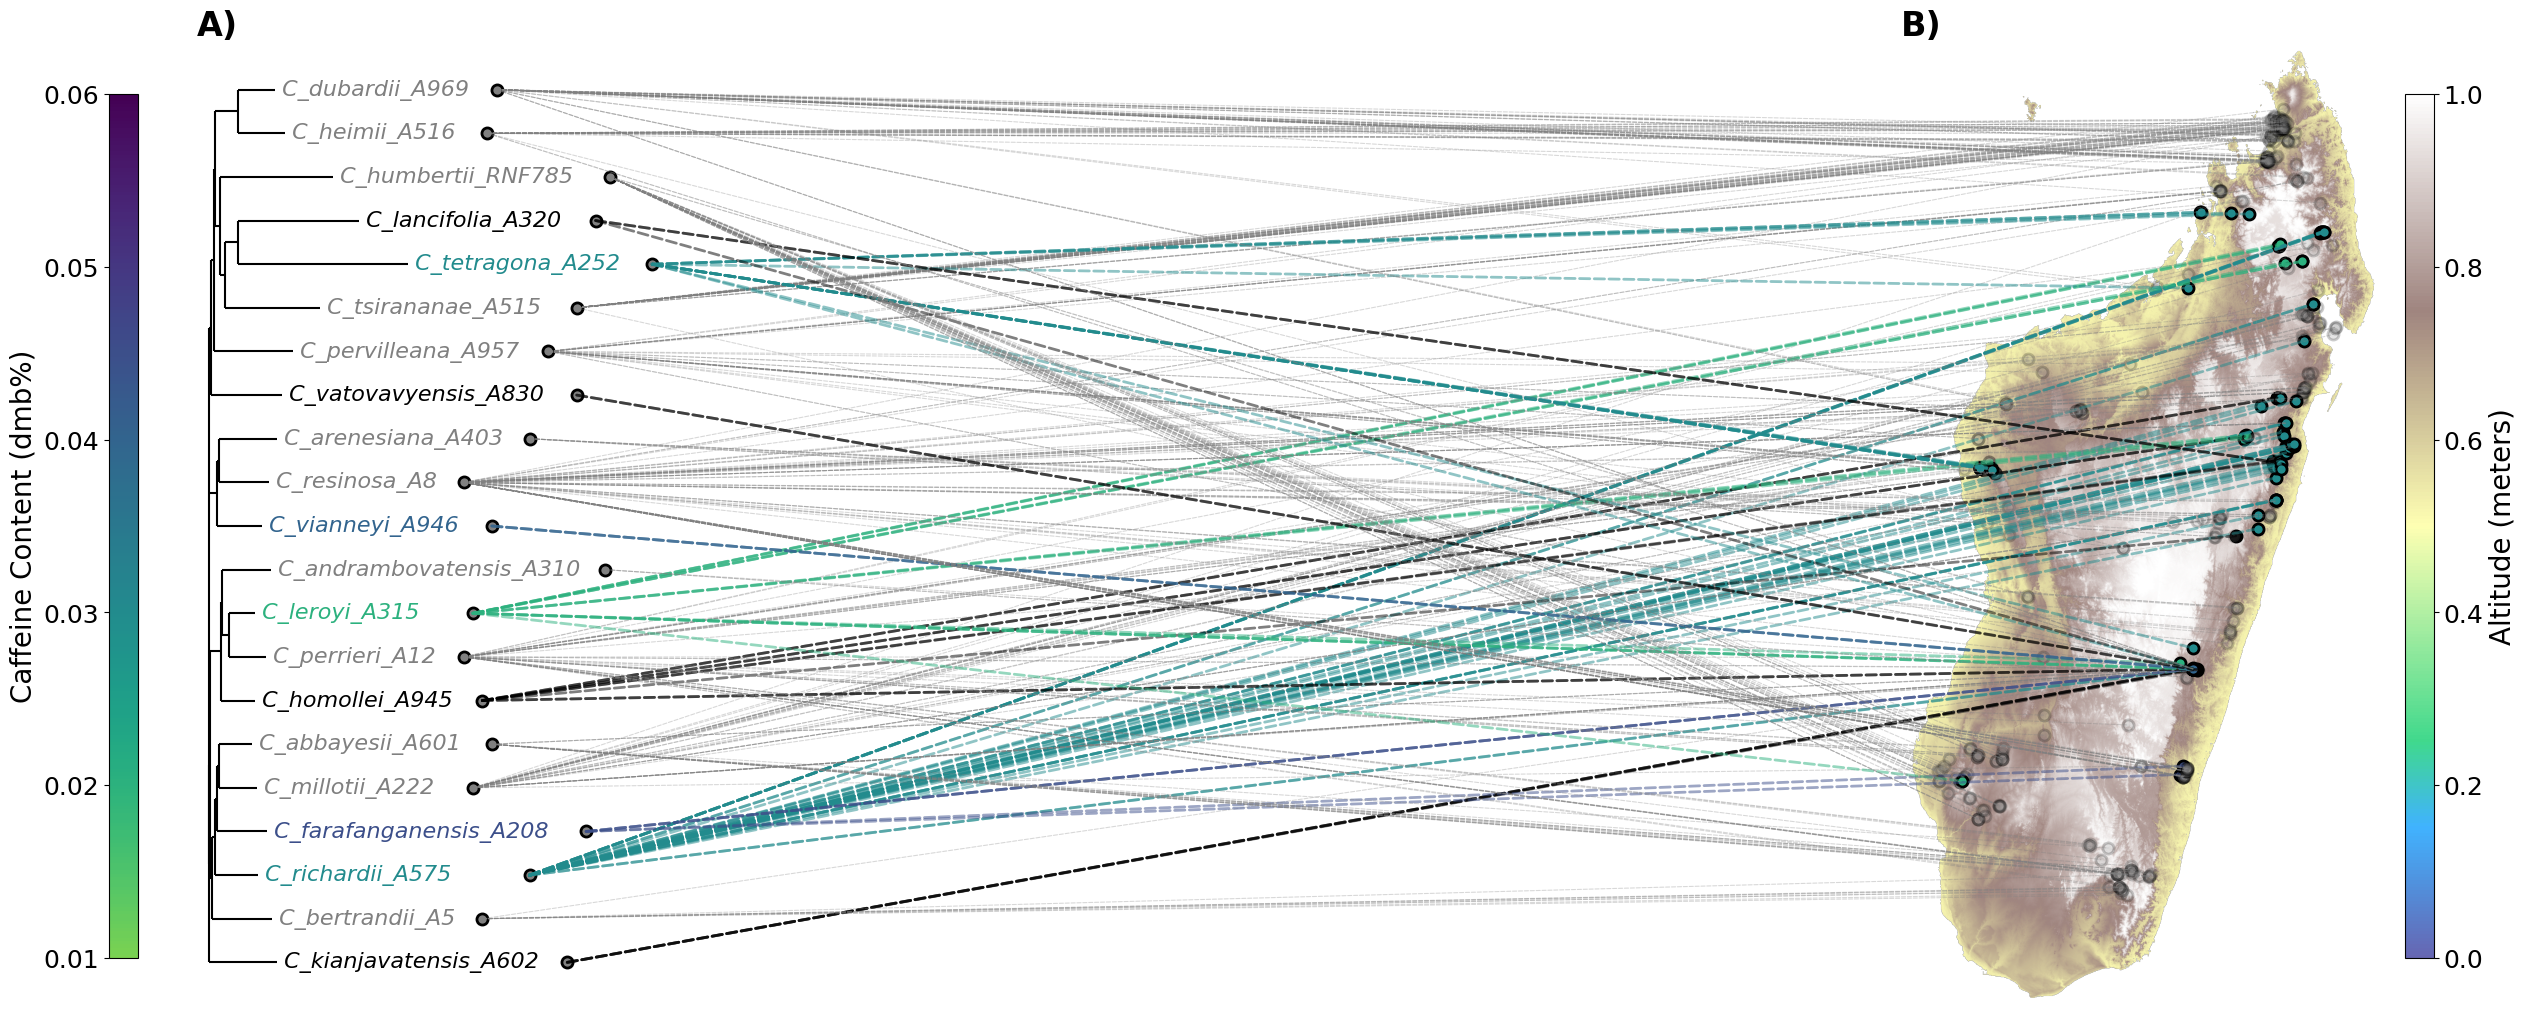

In [4]:
# Create the visualization
fig_raster = plotter_raster.plot(figsize=(35, 12))

# Display in notebook
plotter_raster.show()

### Save the Output

In [5]:
# Save as SVG and PNG
svg_file, png_file, pdf_file = plotter_raster.save(output_dir=str(output_dir), prefix='aligned_caffeine_raster')

print(f"\n✓ Files saved to {output_dir}")


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_raster_to_raster_20260520_181710.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_raster_to_raster_20260520_181710.png
✓ Saved PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_raster_to_raster_20260520_181710.pdf

✓ Files saved to c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output


## Example 2: Visualization with Geographic Map (No Raster)

Create a visualization with just the geographic map and coastlines.

In [6]:
# Initialize plotter WITHOUT raster data
plotter_map = PhyloGeoPlotter(
    nwk_file=str(input_dir / 'aligned_caffeine_without_nodes_w_no_coords_tree.nwk'),
    gps_file=str(input_dir / 'coords_w_caff_wout_no_caff_nodes.csv'),
    offset_file=str(input_dir / 'offsets_caff.csv'),
    # Note: NO raster_file parameter
    vmin=0.01,
    vmax=0.06,
    trait_name='Caffeine Content (%)',
    verbose=True
)

print("\n✓ Map plotter initialized")

PhyloGeoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\aligned_caffeine_without_nodes_w_no_coords_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\coords_w_caff_wout_no_caff_nodes.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\offsets_caff.csv
  ✓ Loaded tree with 21 species
  ✓ Loaded 454 GPS records
  ✓ Loaded 48 node offsets

Configuration:
  Display mode:       Geographic map
  Map extent:         [43, 51, -27, -11]
  Trait name:         Caffeine Content (%)
  Trait value range:  0.010000 - 0.060000

✓ Map plotter initialized


### Create and Display


Creating visualization...
  ✓ Tree plotted
  ✓ Map plotted
  ✓ Colorbar added
  ✓ Connection lines drawn


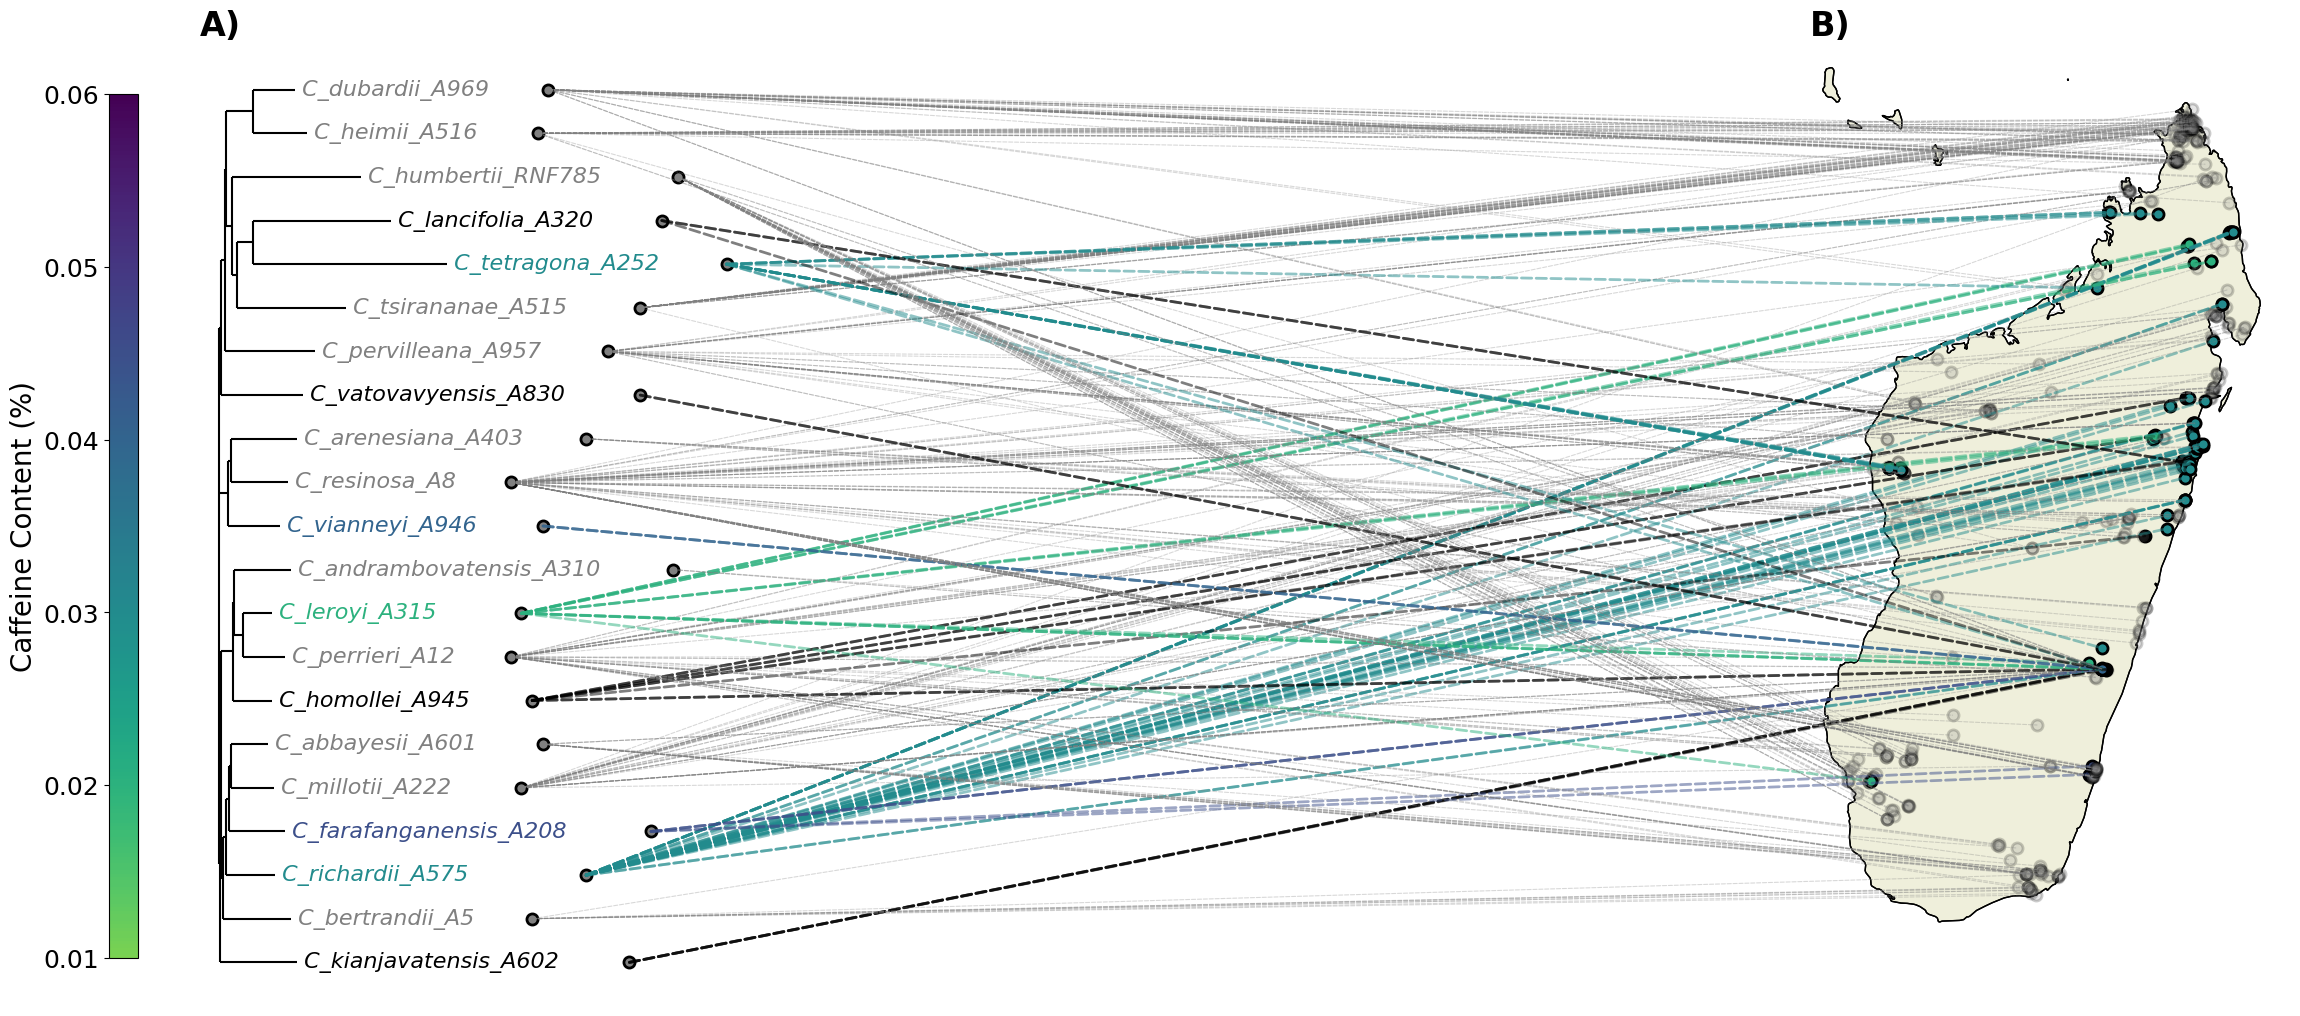

In [7]:
# Create the visualization
fig_map = plotter_map.plot(figsize=(35, 12))

# Display in notebook
plotter_map.show()

### Save the Output

In [8]:
# Save as SVG and PNG
svg_file, png_file, pdf_file = plotter_map.save(output_dir=str(output_dir), prefix='aligned_caffeine_map')

print(f"\n✓ Files saved to {output_dir}")


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_map_to_map_20260520_181718.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_map_to_map_20260520_181718.png
✓ Saved PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_map_to_map_20260520_181718.pdf

✓ Files saved to c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output


## Example 3: Different Raster Bands

Try different environmental raster bands available in your data.

In [9]:
# Band 9 = Forest cover (%)
plotter_forest = PhyloGeoPlotter(
    nwk_file=str(input_dir / 'aligned_caffeine_without_nodes_w_no_coords_tree.nwk'),
    gps_file=str(input_dir / 'coords_w_caff_wout_no_caff_nodes.csv'),
    offset_file=str(input_dir / 'offsets_caff.csv'),
    raster_file=str(input_dir / 'madaclim_enviro.tif'),
    raster_band=9,  # Forest cover
    raster_metadata_file=str(input_dir / 'env_metadata.json'),
    raster_contrast='histogram_eq',  # Less aggressive contrast
    raster_cmap='Greens',  # Green colormap for forest
    vmin=0.01,
    vmax=0.06,
    trait_name='Caffeine Content (%)',
    verbose=True
)

print("\n✓ Forest cover plotter initialized")

PhyloGeoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\aligned_caffeine_without_nodes_w_no_coords_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\coords_w_caff_wout_no_caff_nodes.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\offsets_caff.csv
  ✓ Loaded tree with 21 species
  ✓ Loaded 454 GPS records
  ✓ Loaded 48 node offsets

Raster file: madaclim_enviro.tif
Total bands: 9
CRS: EPSG:32738
Shape: 1528 x 803
--------------------------------------------------------------------------------
Band 1: alt      | Altitude (meters)
Band 2: slo      | Slope (degrees)
Band 3: asp      | Aspect; clockwise from North (degrees)
Band 4: solrad   | Solar radiation (Wh.m-2.day-1)
Band 5: geo      | Rock types (Geology)
Band 6: soi      | Soil types
Band 7: veg


Creating visualization...
  ✓ Tree plotted
  ✓ Enhancing raster contrast (histogram_eq)...
  ✓ Raster plotted with contrast enhancement
  ✓ Colorbar added
  ✓ Connection lines drawn


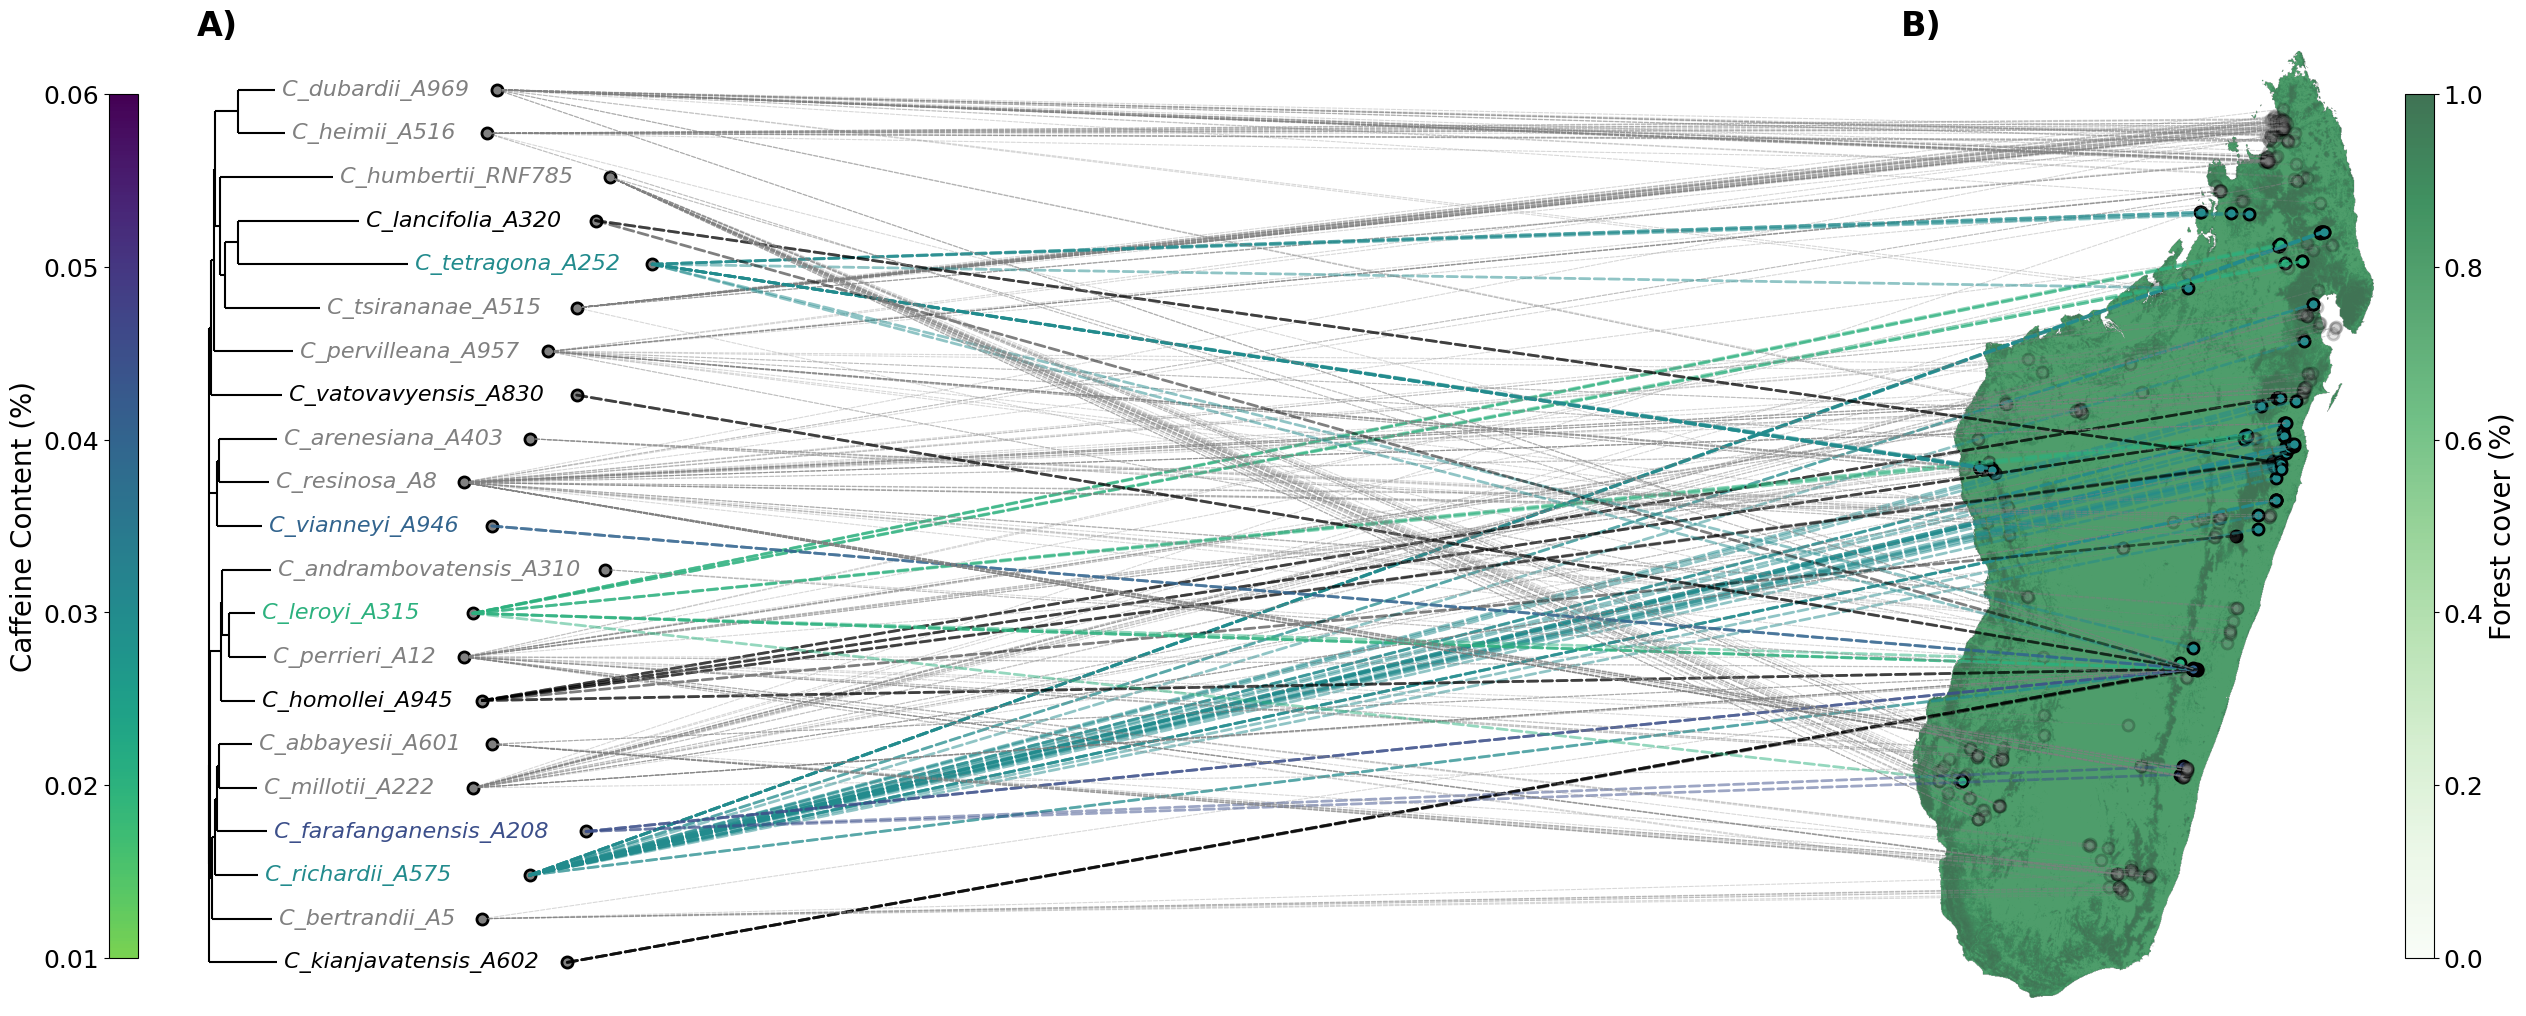

In [10]:
# Create and display
fig_forest = plotter_forest.plot(figsize=(35, 12))
plotter_forest.show()

In [11]:
# Save
svg_file, png_file, pdf_file = plotter_forest.save(output_dir=str(output_dir), prefix='aligned_caffeine_forest')
print(f"✓ Saved to {output_dir}")


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_forest_to_raster_20260520_181724.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_forest_to_raster_20260520_181724.png
✓ Saved PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\aligned_caffeine_forest_to_raster_20260520_181724.pdf
✓ Saved to c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output


## Customization Options

### Raster Contrast Methods

Different contrast enhancement techniques:
- `'percentile'` - Stretch using 0.5-99.5 percentiles (default, good for most data)
- `'histogram_eq'` - Histogram equalization (high contrast, shows details)
- `'sigmoid'` - Sigmoid stretch (smooth, S-curve enhancement)

### Raster Colormaps

Common options:
- `'terrain'` - Elevation-like (browns/greens)
- `'gray'` - Grayscale
- `'viridis'` - Perceptually uniform
- `'Greens'` - Green tones (good for vegetation)
- `'cool'`, `'hot'` - Temperature-like

### Transparency

Adjust these in the code for your needs:
- **Raster transparency**: Line 533 in `tree_to_map_raster.py` - `alpha=0.95` (0.0=transparent, 1.0=opaque)
- **Connection line transparency**: Lines 600-601 - `line_alpha=0.5` for grey, `0.7` for colored
- **GPS point transparency**: Line 580 - `alpha=0.2 if is_zero else 1.0`

## Example 4: Custom Parameters

Fine-tune visualization parameters.

PhyloGeoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\aligned_caffeine_without_nodes_w_no_coords_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\coords_w_caff_wout_no_caff_nodes.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\examples\sample_data\use_case_1\offsets_caff.csv
  ✓ Loaded tree with 21 species
  ✓ Loaded 454 GPS records
  ✓ Loaded 48 node offsets

Raster file: madaclim_enviro.tif
Total bands: 9
CRS: EPSG:32738
Shape: 1528 x 803
--------------------------------------------------------------------------------
Band 1: alt      | Altitude (meters)
Band 2: slo      | Slope (degrees)
Band 3: asp      | Aspect; clockwise from North (degrees)
Band 4: solrad   | Solar radiation (Wh.m-2.day-1)
Band 5: geo      | Rock types (Geology)
Band 6: soi      | Soil types
Band 7: veg

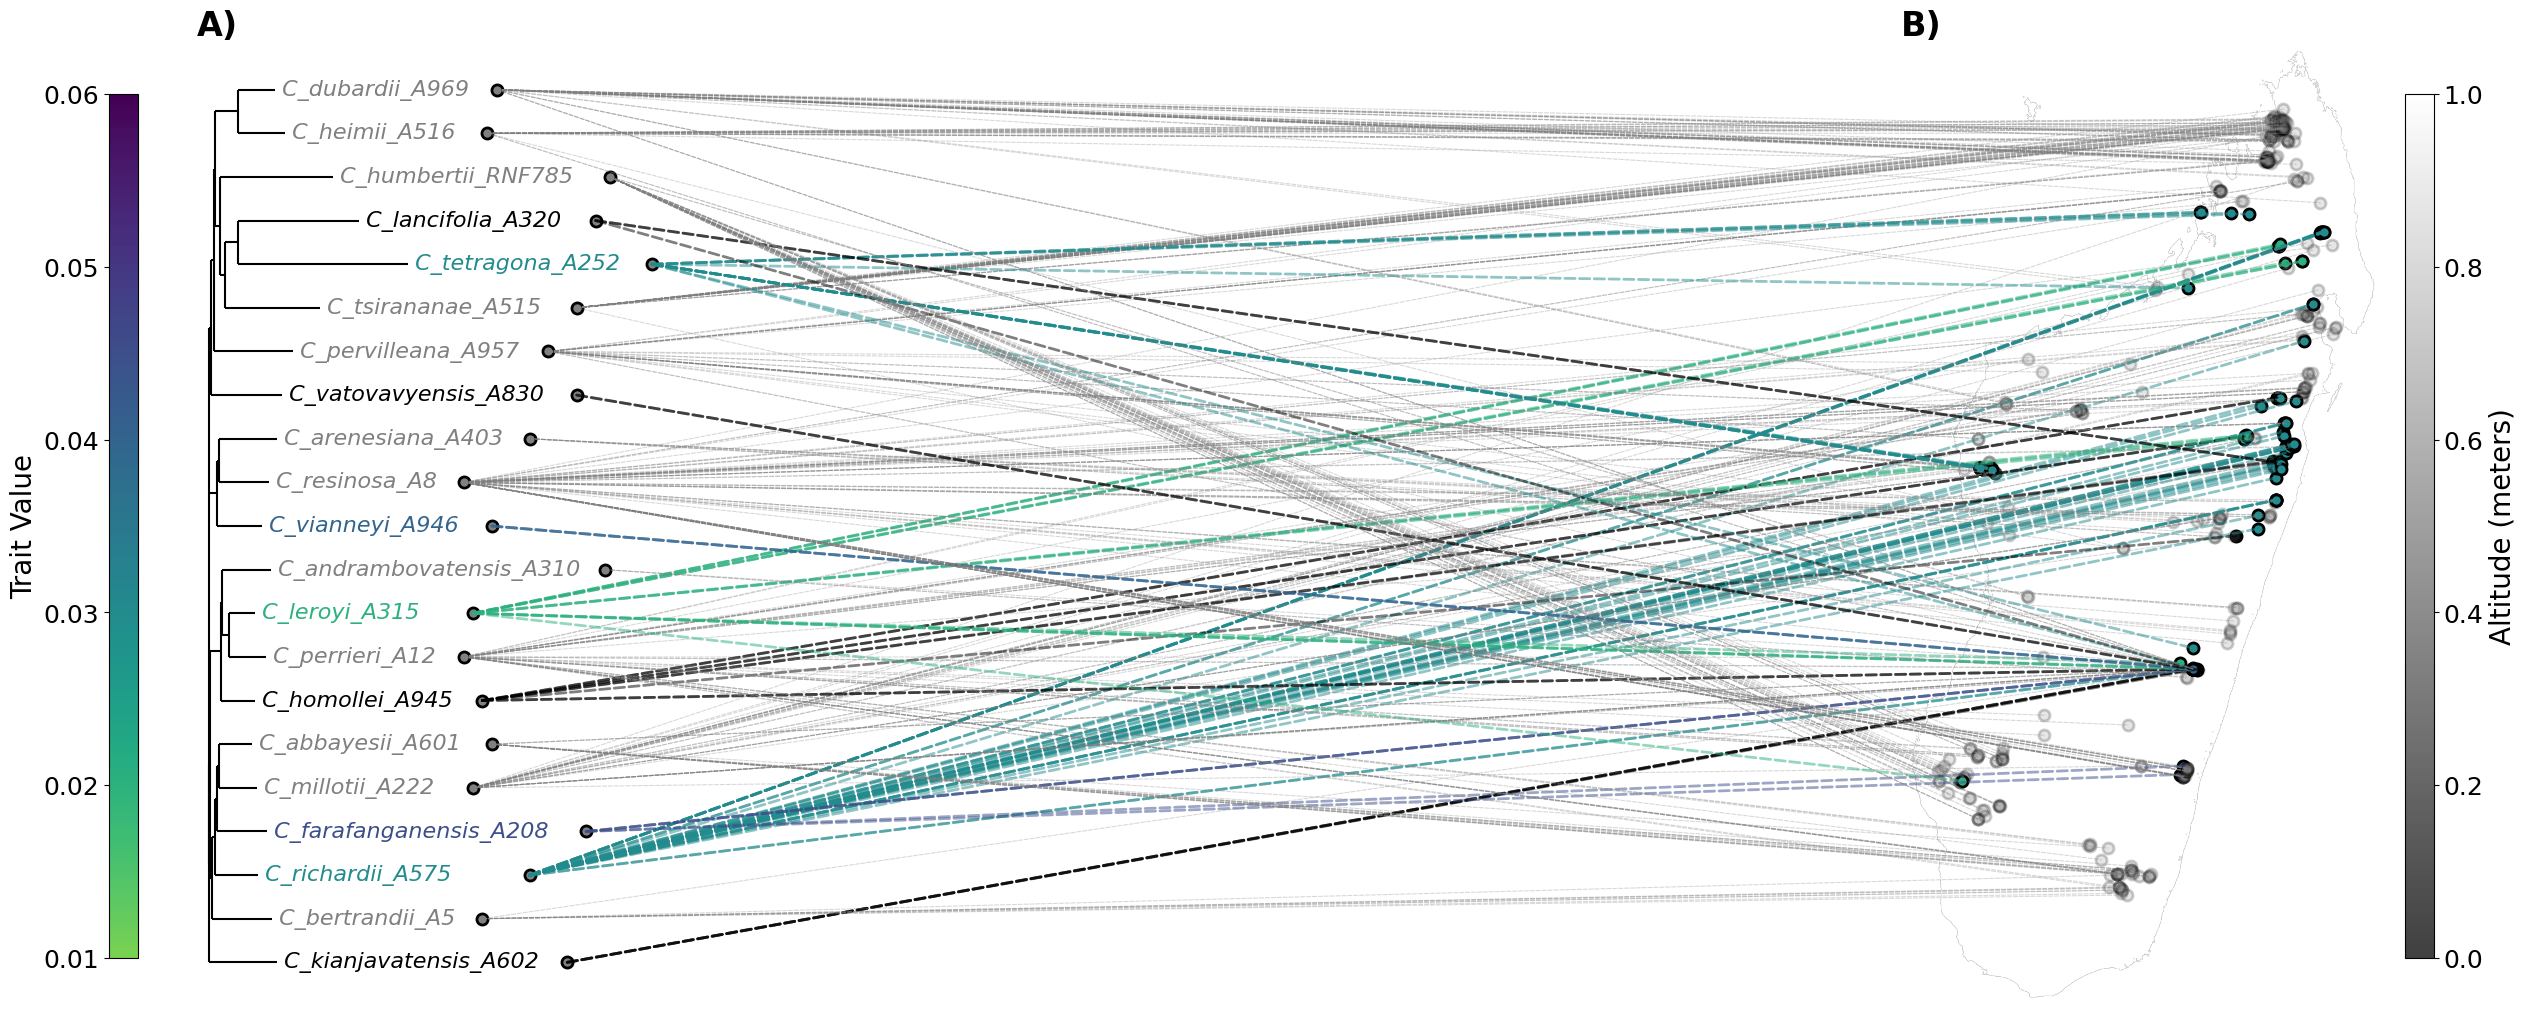

In [12]:
# Create with custom settings
plotter_custom = PhyloGeoPlotter(
    nwk_file=str(input_dir / 'aligned_caffeine_without_nodes_w_no_coords_tree.nwk'),
    gps_file=str(input_dir / 'coords_w_caff_wout_no_caff_nodes.csv'),
    offset_file=str(input_dir / 'offsets_caff.csv'),
    raster_file=str(input_dir / 'madaclim_enviro.tif'),
    raster_band=1,
    raster_metadata_file=str(input_dir / 'env_metadata.json'),
    raster_contrast='sigmoid',  # Try sigmoid
    raster_cmap='grey',  # Grayscale
    extent=[43, 51, -27, -11],  # Madagascar
    vmin=0.01,
    vmax=0.06,
    trait_name='Trait Value',
    verbose=True
)

fig_custom = plotter_custom.plot()
plotter_custom.show()

In [13]:
# Save
plotter_custom.save(output_dir=str(output_dir), prefix='custom_visualization')


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\custom_visualization_to_raster_20260520_181730.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\custom_visualization_to_raster_20260520_181730.png
✓ Saved PDF: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\custom_visualization_to_raster_20260520_181730.pdf


(WindowsPath('c:/Users/adm1/OneDrive - USherbrooke/Documents/memoire/phylocartoplot/output/custom_visualization_to_raster_20260520_181730.svg'),
 WindowsPath('c:/Users/adm1/OneDrive - USherbrooke/Documents/memoire/phylocartoplot/output/custom_visualization_to_raster_20260520_181730.png'),
 WindowsPath('c:/Users/adm1/OneDrive - USherbrooke/Documents/memoire/phylocartoplot/output/custom_visualization_to_raster_20260520_181730.pdf'))

## Cleanup

Close all figures to free memory.

In [14]:
# Close all figures
plotter_raster.close()
plotter_map.close()
plotter_forest.close()
plotter_custom.close()

print("✓ All figures closed")

✓ All figures closed


## Summary

You've learned how to:

✅ Import and initialize `PhyloGeoPlotter`
✅ Create visualizations with raster layers
✅ Create visualizations with geographic maps
✅ Customize contrast enhancement methods
✅ Try different raster bands and colormaps
✅ Save outputs as SVG and PNG
✅ Use transparency and other visual parameters

### Key Files

- **Main class**: `scripts/visualization/tree_to_map_raster.py`
- **Input data**: `input/` directory
- **Output files**: `output/` directory

### Next Steps

1. Explore different raster bands (1-9)
2. Try different contrast methods
3. Customize the map extent for your study region
4. Adjust trait value ranges (vmin, vmax) for your data
5. Use SVG output for publications (vector format)
6. Use PNG output for presentations (raster format)